# HRRR

The High-resolution Rapid Refresh model provides a 3-km, convective allowing forecast for the contiguous United States (CONUS) and Alaska.

Fun fact, Herbie was first designed to get HRRR data.

In [1]:
from herbie.v2 import HRRR
from datetime import datetime

In [2]:
print(HRRR.__doc__)


High-Resolution Rapid Refresh (HRRR) — CONUS.

NOAA's 3-km hourly convection-allowing model covering the
contiguous United States.  Initialized every hour; forecasts extend
to 18 h (48 h for the 00, 06, 12, and 18 UTC cycles).

Parameters
----------
date : str or datetime
    Model initialization datetime (UTC).
step : int or str, default 0
    Forecast lead time in hours (``0``–``18`` or ``0``–``48``).
    Pandas-style timedelta strings (``"6h"``) are also accepted.
product : {'sfc', 'prs', 'nat', 'subh'}, default 'sfc'
    Output product type:

    ``'sfc'``
        2-D surface fields — the most commonly used product.
        ~100 variables, ~3-km horizontal resolution.
    ``'prs'``
        3-D pressure-level fields.
        ~700 variables across 50 pressure levels.
    ``'nat'``
        Native hybrid-sigma-level fields.
    ``'subh'``
        Sub-hourly (15-minute) output (step 00–18 only).

    Aliases: ``surface→sfc``, ``pressure→prs``,
    ``native→nat``, ``subhourly→subh``.
pr

Let's make a Herbie object for some recent HRRR data...

In [3]:
H = HRRR(datetime(2026, 6, 1, 12), step=12)
H

HRRR(2026-06-01 12:00 UTC, F12, product='sfc')

The Herbie object displays all sources it knows about, but it hasn't checked yet if any of these exist. Let's tell Herbie to look for an existing file...

In [4]:
H.resolve()

HRRR(2026-06-01 12:00 UTC, F12, product='sfc', source='aws')

Now you can see that Herbie found an existing file for the requested date and parameter at `aws` or Amazon Web Services.

Just for fun, let's resolve all sources to see where this file exists...


In [5]:
H.resolve("all")

HRRR(2026-06-01 12:00 UTC, F12, product='sfc', source='aws')

This tells us that the HRRR file we asked for exists at all the known sources except `nomads` (which is expected, because NOMADS only has HRRR data for the most recent 2 days).

## Inventory

An inventory lists what fields are available in the file. The inventory is returned as a Polars DataFrame. Calling the inventory method will list all fields. 

In [6]:
H.inventory()

grib_message,start_byte,end_byte,reference_time,source,variable,level,forecast_time
i64,i64,i64,datetime[μs],str,str,str,str
1,0,615309,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""REFC""","""entire atmosphere""","""12 hour fcst"""
2,615310,909042,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""RETOP""","""cloud top""","""12 hour fcst"""
3,909043,1594173,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""var discipline=0 center=7 loca…","""entire atmosphere""","""12 hour fcst"""
4,1594174,1900233,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""VIL""","""entire atmosphere""","""12 hour fcst"""
5,1900234,3319829,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""VIS""","""surface""","""12 hour fcst"""
…,…,…,…,…,…,…,…
169,159907340,159907640,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""ICEC""","""surface""","""12 hour fcst"""
170,159907641,161712001,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""SBT123""","""top of atmosphere""","""12 hour fcst"""
171,161712002,163532576,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""SBT124""","""top of atmosphere""","""12 hour fcst"""


You can filter the inventory for specific fields of interest. There are two ways to do this:

1. Similar to the original Herbie, you may use a regex string to filter the inventory for specific fields, where values in each column are joined together with a `:` character.

For example, here are all temperature fields on pressure levels:

In [7]:
H.inventory(r"TMP:\d+ mb")

grib_message,start_byte,end_byte,reference_time,source,variable,level,forecast_time
i64,i64,i64,datetime[μs],str,str,str,str
15,9546864,10105981,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""500 mb""","""12 hour fcst"""
20,13171505,13734766,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""700 mb""","""12 hour fcst"""
26,17947806,18530643,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""850 mb""","""12 hour fcst"""
30,21044458,21649866,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""925 mb""","""12 hour fcst"""
34,24155136,24781266,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""1000 mb""","""12 hour fcst"""


2. The second inventory filter method is with a Polars expressions or list of expressions. 

This does the same thing as above:

In [8]:
import polars as pl

H.inventory(
    [
        pl.col("variable") == "TMP",
        pl.col("level").str.ends_with("mb"),
    ]
)

grib_message,start_byte,end_byte,reference_time,source,variable,level,forecast_time
i64,i64,i64,datetime[μs],str,str,str,str
15,9546864,10105981,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""500 mb""","""12 hour fcst"""
20,13171505,13734766,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""700 mb""","""12 hour fcst"""
26,17947806,18530643,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""850 mb""","""12 hour fcst"""
30,21044458,21649866,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""925 mb""","""12 hour fcst"""
34,24155136,24781266,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""1000 mb""","""12 hour fcst"""


## Download

We can download that data locally. You can download full files, but most often you only need a few of the fields that are contained in the GRIB files. I like to confirm what I'm downloading using the inventory method before I download.  Here we go using the classic filtering...(

In [9]:
H.inventory(r"(TMP|RH):2 m above")

grib_message,start_byte,end_byte,reference_time,source,variable,level,forecast_time
i64,i64,i64,datetime[μs],str,str,str,str
71,48115758,49410317,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""TMP""","""2 m above ground""","""12 hour fcst"""
75,53579784,55190969,2026-06-01 12:00:00,"""https://noaa-hrrr-bdp-pds.s3.a…","""RH""","""2 m above ground""","""12 hour fcst"""


In [10]:
H.download(r"(TMP|RH):2 m above")

Already exists → /home/blaylock/herbie-data/hrrr.20260601/conus/hrrr.t12z.wrfsfcf12.grib2__subset-0b7637c5

PosixPath('/home/blaylock/herbie-data/hrrr.20260601/conus/hrrr.t12z.wrfsfcf12.grib2__subset-0b7637c5')

Great! We have now downloaded the subset locally. If we look at the Herbie object again, we can see at the bottom that a subset file exists locally.

In [11]:
H

HRRR(2026-06-01 12:00 UTC, F12, product='sfc', source='aws')

## Xarray

To make quick work of the data, Herbie can put that data into an xarray dataset using cfgrib. 

- If the subset you request is local, it will use that.
- If the subset you request is not local, it will download and, by default, remove it. You can have it retain the local subset if you need.

In [12]:
ds = H.xarray(r"(TMP|RH):2 m above")
ds

/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs

<xarray.Dataset> Size: 46MB
Dimensions:              (y: 1059, x: 1799)
Coordinates:
    latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    time                 datetime64[ns] 8B 2026-06-01T12:00:00
    step                 timedelta64[ns] 8B 12:00:00
    heightAboveGround    float64 8B 2.0
    valid_time           datetime64[ns] 8B 2026-06-02
    gribfile_projection  object 8B None
Dimensions without coordinates: y, x
Data variables:
    t2m                  (y, x) float32 8MB ...
    r2                   (y, x) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

If your request is returned on multiple hypercubed, then it returns 

In [13]:
ds = H.xarray("TMP")
ds

Downloading subset (7 messages, 7 groups) from  → hrrr.t12z.wrfsfcf12.grib2__subset-845d7193

/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

✓ Done (1.7s) → /home/blaylock/herbie-data/hrrr.20260601/conus/hrrr.t12z.wrfsfcf12.grib2__subset-845d7193

<xarray.DataTree>
Group: /
├── Group: /heightAboveGround_2
│       Dimensions:              (y: 1059, x: 1799)
│       Coordinates:
│           latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
│           longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
│           time                 datetime64[ns] 8B 2026-06-01T12:00:00
│           step                 timedelta64[ns] 8B 12:00:00
│           heightAboveGround    float64 8B 2.0
│           valid_time           datetime64[ns] 8B 2026-06-02
│           gribfile_projection  object 8B None
│       Dimensions without coordinates: y, x
│       Data variables:
│           t2m                  (y, x) float32 8MB 295.1 295.1 295.1 ... 277.7 277.7
│       Attributes:
│           GRIB_edition:            2
│           GRIB_centre:             kwbc
│           GRIB_centreDescription:  US National Weather Service - NCEP
│           GRIB_subCentre:          0
│           Conventions:             CF-1.7
│           institution:             US National Weather Service - NCEP
├── Group: /isobaricInhPa
│       Dimensions:              (isobaricInhPa: 5, y: 1059, x: 1799)
│       Coordinates:
│         * isobaricInhPa        (isobaricInhPa) float64 40B 1e+03 925.0 ... 700.0 500.0
│           latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
│           longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
│           time                 datetime64[ns] 8B 2026-06-01T12:00:00
│           step                 timedelta64[ns] 8B 12:00:00
│           valid_time           datetime64[ns] 8B 2026-06-02
│           gribfile_projection  object 8B None
│       Dimensions without coordinates: y, x
│       Data variables:
│           t                    (isobaricInhPa, y, x) float32 38MB 293.4 ... 248.3
│       Attributes:
│           GRIB_edition:            2
│           GRIB_centre:             kwbc
│           GRIB_centreDescription:  US National Weather Service - NCEP
│           GRIB_subCentre:          0
│           Conventions:             CF-1.7
│           institution:             US National Weather Service - NCEP
└── Group: /surface_0
        Dimensions:              (y: 1059, x: 1799)
        Coordinates:
            latitude             (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
            longitude            (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
            time                 datetime64[ns] 8B 2026-06-01T12:00:00
            step                 timedelta64[ns] 8B 12:00:00
            surface              float64 8B 0.0
            valid_time           datetime64[ns] 8B 2026-06-02
            gribfile_projection  object 8B None
        Dimensions without coordinates: y, x
        Data variables:
            t                    (y, x) float32 8MB 296.8 296.8 296.8 ... 277.9 277.9
        Attributes:
            GRIB_edition:            2
            GRIB_centre:             kwbc
            GRIB_centreDescription:  US National Weather Service - NCEP
            GRIB_subCentre:          0
            Conventions:             CF-1.7
            institution:             US National Weather Service - NCEP

## Quick Plot
Let's make a quick plot of a field using Herbie's EasyMap wrapper for Cartopy.

Downloading subset (1 messages, 1 groups) from  → hrrr.t12z.wrfsfcf12.grib2__subset-f3dea3d8

/home/blaylock/GITHUB/Herbie/.venv/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

✓ Done (0.7s) → /home/blaylock/herbie-data/hrrr.20260601/conus/hrrr.t12z.wrfsfcf12.grib2__subset-f3dea3d8

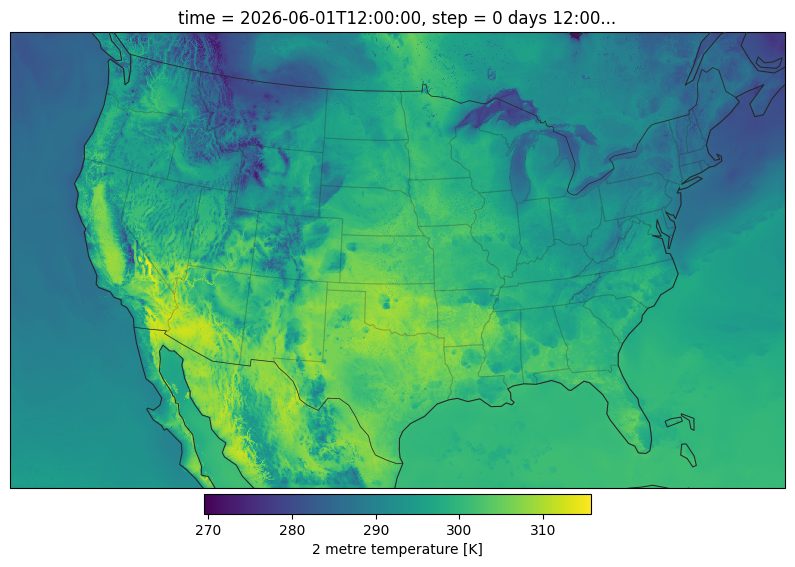

In [14]:
from herbie.toolbox import EasyMap, pc

# Get Data
ds = H.xarray("TMP:2 m above ground")

# Create Cartopy Map
ax = EasyMap(figsize=(10, 8), crs=ds.herbie.crs).STATES().BORDERS().ax

# Plot data on map

ds.t2m.plot(
    ax=ax,
    x="longitude",
    y="latitude",
    transform=pc,
    cbar_kwargs=dict(pad=0.01, shrink=0.5, orientation="horizontal"),
)

---

## Conclusion

I hope this helps you get started using Herbie. The important parts are to 

1. Create a Herbie object for the date and product you want.

1. Determine what fields you want using inventory filters

1. Download file subsets or load data into xarray.

1. Put that data to use; make pretty pictures, crunch some numbers, have fun!